# Mutual Fund Analytics - Performance Analytics

## Project Overview

This notebook performs financial performance analysis of 40 mutual fund schemes using historical NAV data.

### Objectives

- Compute daily returns
- Calculate CAGR (1-Year, 3-Year, 5-Year)
- Compute Sharpe Ratio
- Compute Sortino Ratio
- Calculate Alpha & Beta
- Calculate Maximum Drawdown
- Build Fund Scorecard (0–100)
- Compare funds with benchmark indices

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go

from scipy.stats import linregress

import warnings
warnings.filterwarnings("ignore")

plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

pd.set_option("display.max_columns", None)

print("Libraries Loaded Successfully!")

Libraries Loaded Successfully!


In [2]:
# Load datasets

fund_master = pd.read_csv("../data/processed/01_fund_master.csv")

nav_history = pd.read_csv("../data/processed/02_nav_history.csv")

performance = pd.read_csv("../data/processed/07_scheme_performance.csv")

benchmark = pd.read_csv("../data/processed/10_benchmark_indices.csv")

print("Datasets Loaded Successfully!")

Datasets Loaded Successfully!


In [3]:
# Convert dates

nav_history["date"] = pd.to_datetime(nav_history["date"])

benchmark["date"] = pd.to_datetime(benchmark["date"])

# Sort NAV history
nav_history = nav_history.sort_values(
    ["amfi_code", "date"]
)

# Display
nav_history.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [4]:
print("Fund Master :", fund_master.shape)

print("NAV History :", nav_history.shape)

print("Performance :", performance.shape)

print("Benchmark :", benchmark.shape)

Fund Master : (40, 15)
NAV History : (46000, 3)
Performance : (40, 19)
Benchmark : (8050, 3)


In [5]:
# Compute daily returns for each mutual fund

nav_history["daily_return"] = (
    nav_history
    .groupby("amfi_code")["nav"]
    .pct_change()
)

nav_history.head(10)

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210
5,100016,2022-01-10,510.7136,-0.008639
6,100016,2022-01-11,513.5542,0.005562
7,100016,2022-01-12,512.3195,-0.002404
8,100016,2022-01-13,510.2445,-0.004050
9,100016,2022-01-14,514.3636,0.008073


In [6]:
daily_returns = nav_history.dropna(subset=["daily_return"])

print(daily_returns.head())

print("\nTotal Records :", len(daily_returns))

   amfi_code       date       nav  daily_return
1     100016 2022-01-04  515.0971     -0.010306
2     100016 2022-01-05  521.7239      0.012865
3     100016 2022-01-06  515.7880     -0.011377
4     100016 2022-01-07  515.1639     -0.001210
5     100016 2022-01-10  510.7136     -0.008639

Total Records : 45960


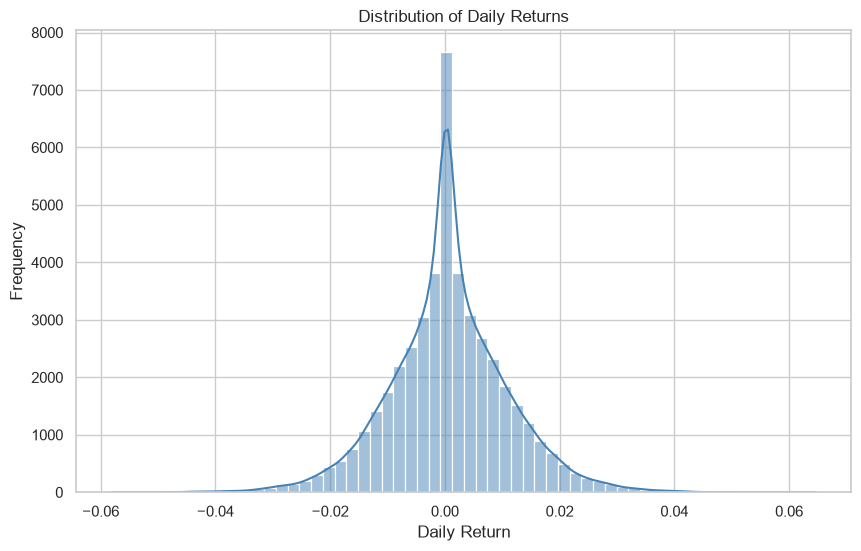

In [7]:
plt.figure(figsize=(10,6))

sns.histplot(
    daily_returns["daily_return"],
    bins=60,
    kde=True,
    color="steelblue"
)

plt.title("Distribution of Daily Returns")

plt.xlabel("Daily Return")

plt.ylabel("Frequency")

plt.show()

In [8]:
daily_returns["daily_return"].describe()

count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64

## Insight 1

The distribution of daily returns is centered close to zero, which is typical for mutual fund NAV movements. Most daily changes are relatively small, while a few extreme values represent periods of high market volatility.

In [9]:
def calculate_cagr(start_nav, end_nav, years):
    """
    Calculate Compound Annual Growth Rate (CAGR)
    """
    if start_nav <= 0 or end_nav <= 0:
        return np.nan

    return ((end_nav / start_nav) ** (1 / years) - 1) * 100

In [10]:
cagr_results = []

for amfi_code in nav_history["amfi_code"].unique():

    fund = nav_history[nav_history["amfi_code"] == amfi_code].sort_values("date")

    start_nav = fund.iloc[0]["nav"]
    end_nav = fund.iloc[-1]["nav"]

    cagr_1yr = calculate_cagr(start_nav, end_nav, 1)
    cagr_3yr = calculate_cagr(start_nav, end_nav, 3)
    cagr_5yr = calculate_cagr(start_nav, end_nav, 5)

    cagr_results.append({
        "amfi_code": amfi_code,
        "CAGR_1Y": round(cagr_1yr, 2),
        "CAGR_3Y": round(cagr_3yr, 2),
        "CAGR_5Y": round(cagr_5yr, 2)
    })

cagr_df = pd.DataFrame(cagr_results)

cagr_df.head()

,amfi_code,CAGR_1Y,CAGR_3Y,CAGR_5Y
0,100016,12.13,3.89,2.32
1,100025,21.16,6.61,3.91
2,100033,218.51,47.13,26.07
3,101206,153.46,36.34,20.44
4,101207,39.95,11.86,6.95


In [11]:
cagr_df = cagr_df.merge(
    fund_master[
        ["amfi_code", "scheme_name", "fund_house"]
    ],
    on="amfi_code",
    how="left"
)

cagr_df.head()

,amfi_code,CAGR_1Y,CAGR_3Y,CAGR_5Y,scheme_name,fund_house
0,100016,12.13,3.89,2.32,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund
1,100025,21.16,6.61,3.91,HDFC Short Term Debt Fund - Regular - Growth,HDFC Mutual Fund
2,100033,218.51,47.13,26.07,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund
3,101206,153.46,36.34,20.44,ABSL Frontline Equity Fund - Regular - Growth,Aditya Birla Sun Life MF
4,101207,39.95,11.86,6.95,ABSL Small Cap Fund - Regular - Growth,Aditya Birla Sun Life MF


In [12]:
cagr_df = cagr_df.sort_values(
    "CAGR_5Y",
    ascending=False
)

cagr_df.head(10)



,amfi_code,CAGR_1Y,CAGR_3Y,CAGR_5Y,scheme_name,fund_house
25,120505,248.68,51.64,28.38,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF
21,119598,244.04,50.96,28.03,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund
39,149324,242.49,50.74,27.92,DSP Small Cap Fund - Regular - Growth,DSP Mutual Fund
36,148569,238.66,50.17,27.63,Mirae Asset Tax Saver Fund - Regular - Growth,Mirae Asset MF
34,148567,227.78,48.55,26.80,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset MF
30,120843,227.05,48.44,26.74,Kotak Flexicap Fund - Regular - Growth,Kotak Mahindra MF
2,100033,218.51,47.13,26.07,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund
38,149323,212.72,46.23,25.61,DSP Midcap Fund - Regular - Growth,DSP Mutual Fund
16,119094,198.46,43.98,24.45,Axis Midcap Fund - Regular - Growth,Axis Mutual Fund
19,119551,174.56,40.03,22.38,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund


In [13]:
cagr_df.to_csv(
    "../reports/cagr_comparison.csv",
    index=False
)

print("CAGR comparison saved successfully!")

CAGR comparison saved successfully!


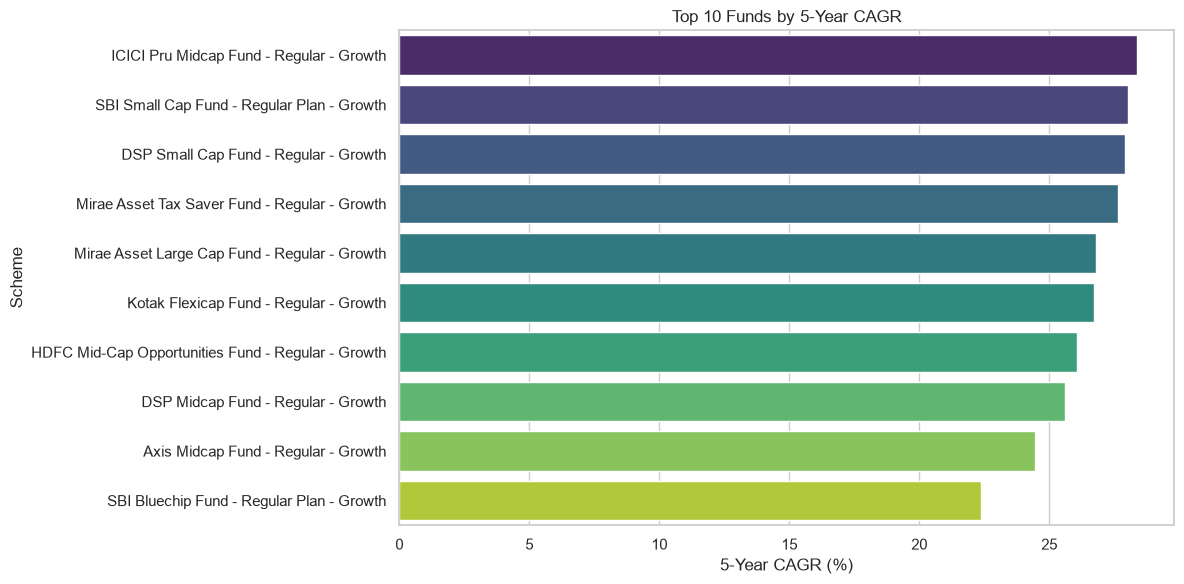

In [14]:
plt.figure(figsize=(12,6))

top10 = cagr_df.head(10)

sns.barplot(
    data=top10,
    x="CAGR_5Y",
    y="scheme_name",
    hue="scheme_name",
    palette="viridis",
    legend=False
)

plt.title("Top 10 Funds by 5-Year CAGR")

plt.xlabel("5-Year CAGR (%)")

plt.ylabel("Scheme")

plt.tight_layout()

plt.show()

## Insight 2

The CAGR comparison highlights the funds that delivered the strongest long-term annualized growth. Higher 5-year CAGR values indicate consistent wealth creation over the investment period, making these funds attractive for long-term investors.

In [15]:
# Annual and daily risk-free rate
risk_free_rate = 0.065          # 6.5% annual
daily_rf = risk_free_rate / 252

print("Annual Risk-Free Rate :", risk_free_rate)
print("Daily Risk-Free Rate  :", daily_rf)

Annual Risk-Free Rate : 0.065
Daily Risk-Free Rate  : 0.00025793650793650796


In [16]:
sharpe_results = []

for amfi_code in daily_returns["amfi_code"].unique():

    fund = daily_returns[daily_returns["amfi_code"] == amfi_code]

    mean_return = fund["daily_return"].mean()

    std_return = fund["daily_return"].std()

    if std_return == 0:
        sharpe = np.nan
    else:
        sharpe = ((mean_return - daily_rf) / std_return) * np.sqrt(252)

    sharpe_results.append({
        "amfi_code": amfi_code,
        "Sharpe_Ratio": round(sharpe, 3)
    })

sharpe_df = pd.DataFrame(sharpe_results)

sharpe_df.head()

,amfi_code,Sharpe_Ratio
0,100016,-0.202
1,100025,-0.567
2,100033,1.094
3,101206,1.027
4,101207,0.163


In [17]:
sharpe_df = sharpe_df.merge(
    fund_master[
        ["amfi_code", "scheme_name", "fund_house"]
    ],
    on="amfi_code",
    how="left"
)

sharpe_df.head()

,amfi_code,Sharpe_Ratio,scheme_name,fund_house
0,100016,-0.202,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund
1,100025,-0.567,HDFC Short Term Debt Fund - Regular - Growth,HDFC Mutual Fund
2,100033,1.094,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund
3,101206,1.027,ABSL Frontline Equity Fund - Regular - Growth,Aditya Birla Sun Life MF
4,101207,0.163,ABSL Small Cap Fund - Regular - Growth,Aditya Birla Sun Life MF


In [18]:
sharpe_df = sharpe_df.sort_values(
    "Sharpe_Ratio",
    ascending=False
)

sharpe_df.reset_index(drop=True, inplace=True)

sharpe_df.head(10)

,amfi_code,Sharpe_Ratio,scheme_name,fund_house
0,148567,1.448,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset MF
1,120843,1.307,Kotak Flexicap Fund - Regular - Growth,Kotak Mahindra MF
2,148569,1.235,Mirae Asset Tax Saver Fund - Regular - Growth,Mirae Asset MF
3,119551,1.208,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund
4,120505,1.180,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF
5,149323,1.132,DSP Midcap Fund - Regular - Growth,DSP Mutual Fund
6,100033,1.094,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund
7,118632,1.082,Nippon India Large Cap Fund - Regular - Growth,Nippon India MF
8,101206,1.027,ABSL Frontline Equity Fund - Regular - Growth,Aditya Birla Sun Life MF
9,120504,1.027,ICICI Pru Bluechip Fund - Direct - Growth,ICICI Prudential MF


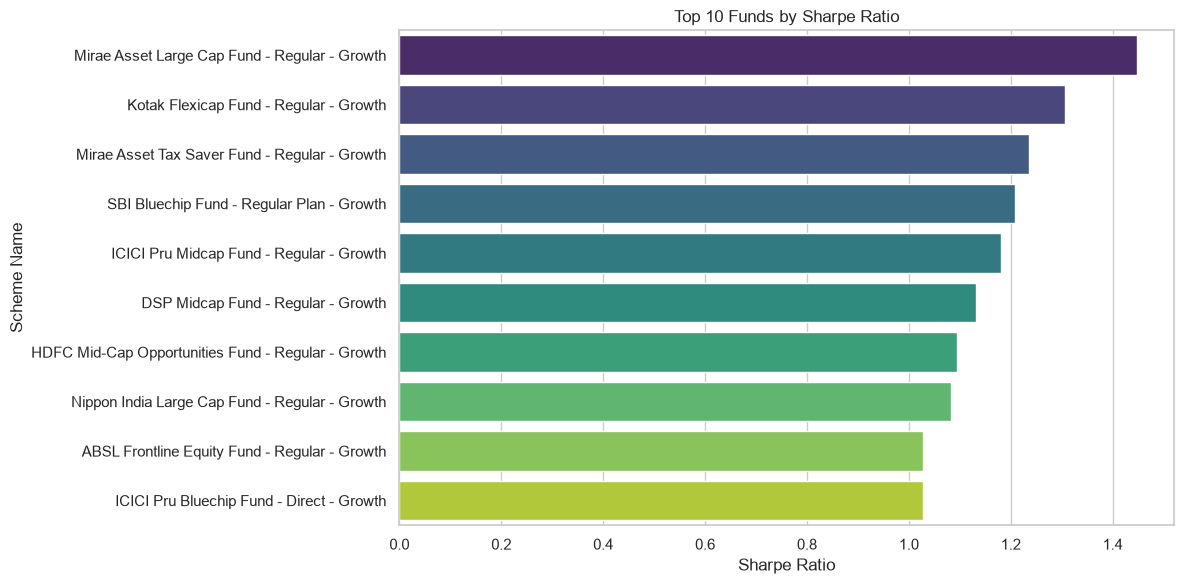

In [19]:
plt.figure(figsize=(12,6))

top10 = sharpe_df.head(10)

sns.barplot(
    data=top10,
    x="Sharpe_Ratio",
    y="scheme_name",
    hue="scheme_name",
    palette="viridis",
    legend=False
)

plt.title("Top 10 Funds by Sharpe Ratio")

plt.xlabel("Sharpe Ratio")

plt.ylabel("Scheme Name")

plt.tight_layout()

plt.show()

In [20]:
sharpe_df.to_csv(
    "../reports/sharpe_ratio.csv",
    index=False
)

print("Sharpe Ratio results saved successfully!")

Sharpe Ratio results saved successfully!


## Insight 3

The Sharpe Ratio measures the return generated for each unit of risk. Funds with higher Sharpe Ratios provide better risk-adjusted performance, making them more attractive to long-term investors compared to funds with similar returns but higher volatility.

In [21]:
# Calculate Sortino Ratio

sortino_results = []

for amfi_code in daily_returns["amfi_code"].unique():

    fund = daily_returns[daily_returns["amfi_code"] == amfi_code]

    mean_return = fund["daily_return"].mean()

    # Negative returns only
    downside_returns = fund[fund["daily_return"] < 0]["daily_return"]

    downside_std = downside_returns.std()

    if pd.isna(downside_std) or downside_std == 0:
        sortino = np.nan
    else:
        sortino = ((mean_return - daily_rf) / downside_std) * np.sqrt(252)

    sortino_results.append({
        "amfi_code": amfi_code,
        "Sortino_Ratio": round(sortino, 3)
    })

sortino_df = pd.DataFrame(sortino_results)

sortino_df.head()

,amfi_code,Sortino_Ratio
0,100016,-0.351
1,100025,-0.942
2,100033,1.829
3,101206,1.800
4,101207,0.277


In [22]:
sortino_df = sortino_df.merge(
    fund_master[
        ["amfi_code", "scheme_name", "fund_house"]
    ],
    on="amfi_code",
    how="left"
)

sortino_df.head()

,amfi_code,Sortino_Ratio,scheme_name,fund_house
0,100016,-0.351,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund
1,100025,-0.942,HDFC Short Term Debt Fund - Regular - Growth,HDFC Mutual Fund
2,100033,1.829,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund
3,101206,1.800,ABSL Frontline Equity Fund - Regular - Growth,Aditya Birla Sun Life MF
4,101207,0.277,ABSL Small Cap Fund - Regular - Growth,Aditya Birla Sun Life MF


In [23]:
sortino_df = sortino_df.sort_values(
    "Sortino_Ratio",
    ascending=False
)

sortino_df.reset_index(drop=True, inplace=True)

sortino_df.head(10)

,amfi_code,Sortino_Ratio,scheme_name,fund_house
0,148567,2.386,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset MF
1,120843,2.364,Kotak Flexicap Fund - Regular - Growth,Kotak Mahindra MF
2,148569,2.147,Mirae Asset Tax Saver Fund - Regular - Growth,Mirae Asset MF
3,119551,2.140,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund
4,120505,2.029,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF
5,149323,1.875,DSP Midcap Fund - Regular - Growth,DSP Mutual Fund
6,118632,1.850,Nippon India Large Cap Fund - Regular - Growth,Nippon India MF
7,100033,1.829,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund
8,120504,1.805,ICICI Pru Bluechip Fund - Direct - Growth,ICICI Prudential MF
9,101206,1.800,ABSL Frontline Equity Fund - Regular - Growth,Aditya Birla Sun Life MF


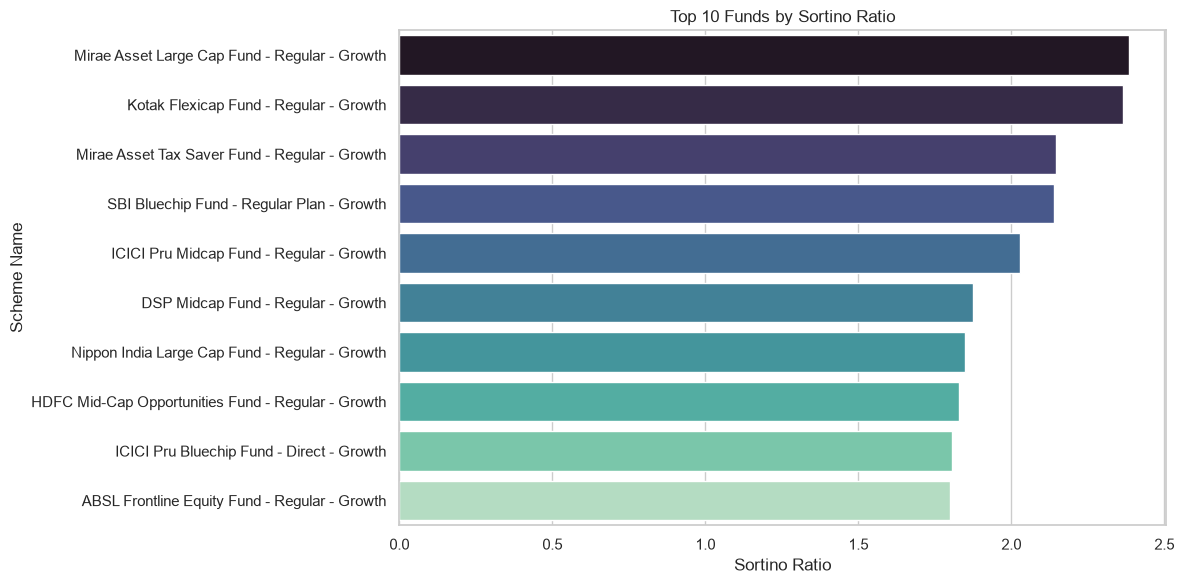

In [24]:
plt.figure(figsize=(12,6))

top10 = sortino_df.head(10)

sns.barplot(
    data=top10,
    x="Sortino_Ratio",
    y="scheme_name",
    hue="scheme_name",
    palette="mako",
    legend=False
)

plt.title("Top 10 Funds by Sortino Ratio")

plt.xlabel("Sortino Ratio")

plt.ylabel("Scheme Name")

plt.tight_layout()

plt.show()

In [25]:
sortino_df.to_csv(
    "../reports/sortino_ratio.csv",
    index=False
)

print("Sortino Ratio results saved successfully!")

Sortino Ratio results saved successfully!


## Insight 4

The Sortino Ratio evaluates performance by considering only downside risk. Funds with higher Sortino Ratios delivered stronger returns while minimizing negative return volatility, making them suitable for investors focused on downside protection.


In [26]:
# Select Nifty 100 benchmark

nifty100 = benchmark[
    benchmark["index_name"].str.contains("Nifty 100", case=False, na=False)
].copy()

# Sort by date
nifty100 = nifty100.sort_values("date")

# Calculate daily benchmark returns
nifty100["benchmark_return"] = nifty100["close_value"].pct_change()

# Remove first NaN row
nifty100 = nifty100.dropna()

nifty100.head()

,date,index_name,close_value,benchmark_return


In [27]:
alpha_beta_results = []

for amfi_code in daily_returns["amfi_code"].unique():

    # Fund daily returns
    fund = daily_returns[
        daily_returns["amfi_code"] == amfi_code
    ][["date", "daily_return"]]

    # Merge with benchmark returns
    merged = pd.merge(
        fund,
        nifty100[["date", "benchmark_return"]],
        on="date",
        how="inner"
    )

    # Skip if insufficient data
    if len(merged) < 30:
        continue

    # Linear Regression
    slope, intercept, r_value, p_value, std_err = linregress(
        merged["benchmark_return"],
        merged["daily_return"]
    )

    alpha = intercept * 252
    beta = slope

    alpha_beta_results.append({
        "amfi_code": amfi_code,
        "Alpha": round(alpha, 4),
        "Beta": round(beta, 4),
        "R_Squared": round(r_value**2, 4)
    })

alpha_beta_df = pd.DataFrame(alpha_beta_results)

alpha_beta_df.head()

""


In [29]:
alpha_beta_df = alpha_beta_df.merge(
    fund_master[
        ["amfi_code", "scheme_name", "fund_house"]
    ],
    on="amfi_code",
    how="left"
)

alpha_beta_df.head()

KeyError: 'amfi_code'